<a href="https://colab.research.google.com/github/khoirul2003/PVCK_Ganjil_2025/blob/main/week11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

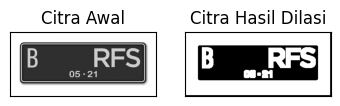

In [3]:
def dilasi_citra(F, w):
    # Ukuran citra
    p, q = F.shape
    imgD = np.zeros((p, q), dtype=np.uint8)

    # Struktur elemen dilasi (SED)
    SED = np.ones((w, w), dtype=np.uint8)
    offset = (w - 1) // 2

    # Proses dilasi
    for i in range(offset, p - offset):
        for j in range(offset, q - offset):
            temp = F[i - offset:i + offset + 1, j - offset:j + offset + 1]
            product = temp * SED
            imgD[i, j] = np.max(product)

    return imgD

# Load dan threshold citra
img_d = cv2.imread('/content/drive/MyDrive/Images/plat_nomor.png', 0)
ret, thresh = cv2.threshold(img_d, 125, 200, cv2.THRESH_BINARY)

# Parameter dan proses dilasi
w = 5
imgD = dilasi_citra(thresh, w)

# Tampilkan hasil
plt.subplot(131), plt.imshow(img_d, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(132), plt.imshow(imgD, cmap='gray')
plt.title('Citra Hasil Dilasi'), plt.xticks([]), plt.yticks([])

plt.show()


[[1 1 1]
 [1 1 1]
 [1 1 1]]


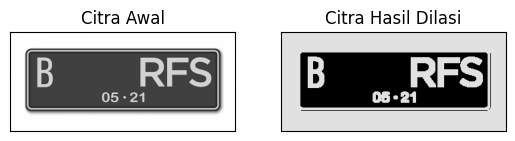

In [5]:
img = cv2.imread('/content/drive/MyDrive/Images/plat_nomor.png')
#img = cv2.imread('morp.jpg',0)
ret, thresh = cv2.threshold(img, 127, 225, cv2.THRESH_BINARY)
kernel = np.ones((3,3),np.uint16)
dilasi = cv2.dilate(thresh,kernel,iterations = 1)
print(kernel)
plt.subplot(121),plt.imshow(img),plt.title('Citra Awal')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(dilasi),plt.title('Citra Hasil Dilasi')
plt.xticks([]), plt.yticks([])
plt.show()

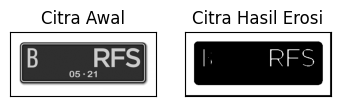

In [7]:
def erosi_citra(F, k):
    # Ukuran citra
    m, n = F.shape
    imgE = np.zeros((m, n), dtype=np.uint8)

    # Struktur elemen erosi (SE)
    SE = np.ones((k, k), dtype=np.uint8)
    offset = (k - 1) // 2

    # Proses erosi
    for i in range(offset, m - offset):
        for j in range(offset, n - offset):
            temp = F[i - offset:i + offset + 1, j - offset:j + offset + 1]
            product = temp * SE
            imgE[i, j] = np.min(product)

    return imgE

# Load dan threshold citra
img_e = cv2.imread('/content/drive/MyDrive/Images/plat_nomor.png', 0)
ret1, thresh1 = cv2.threshold(img_e, 175, 225, cv2.THRESH_BINARY)

# Parameter dan proses erosi
k = 5
imgE = erosi_citra(thresh1, k)

# Tampilkan hasil
plt.subplot(131), plt.imshow(img_e, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(132), plt.imshow(imgE, cmap='gray')
plt.title('Citra Hasil Erosi'), plt.xticks([]), plt.yticks([])

plt.show()


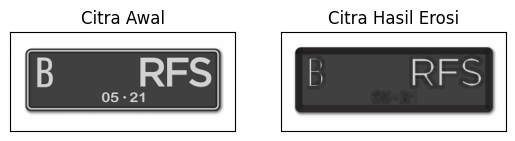

In [8]:
img = cv2.imread('/content/drive/MyDrive/Images/plat_nomor.png')
kernel = np.ones((5,5),np.uint8)
erosion = cv2.erode(img,kernel,iterations = 1)
plt.subplot(121),plt.imshow(img),plt.title('Citra Awal')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(erosion),plt.title('Citra Hasil Erosi')
plt.xticks([]), plt.yticks([])
plt.show()

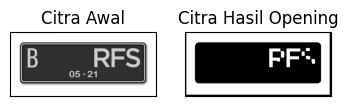

In [11]:
img_o= cv2.imread('/content/drive/MyDrive/Images/plat_nomor.png',0) #
reto, thresho = cv2.threshold(img_o, 127, 225,
cv2.THRESH_BINARY)
k=7
imgO = dilasi_citra(erosi_citra(thresho,k),k)
plt.subplot(131),plt.imshow(img_o,cmap = 'gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(imgO,cmap = 'gray')
plt.title('Citra Hasil Opening'), plt.xticks([]), plt.yticks([])
plt.show()

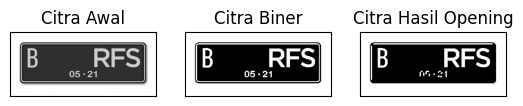

In [12]:
img = cv2.imread('/content/drive/MyDrive/Images/plat_nomor.png',0)
ret, thresh = cv2.threshold(img, 127, 225, cv2.THRESH_BINARY)
kernel = np.ones((3,3),np.uint8)
openn = cv2.morphologyEx(thresh,cv2.MORPH_OPEN, kernel)
plt.subplot(131),plt.imshow(img,cmap = 'gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(thresh,cmap = 'gray')
plt.title('Citra Biner'), plt.xticks([]), plt.yticks([])
plt.subplot(133),plt.imshow(openn,cmap = 'gray')
plt.title('Citra Hasil Opening'), plt.xticks([]),
plt.yticks([])
plt.show()

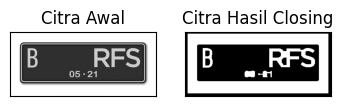

In [15]:
img_c= cv2.imread('/content/drive/MyDrive/Images/plat_nomor.png',0) #
retc, threshc = cv2.threshold(img_c, 127, 225,cv2.THRESH_BINARY)
k=7
imgC = erosi_citra(dilasi_citra(threshc,k),k)
plt.subplot(131),plt.imshow(img_c,cmap = 'gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(imgC,cmap = 'gray')
plt.title('Citra Hasil Closing'), plt.xticks([]),
plt.yticks([])
plt.show()

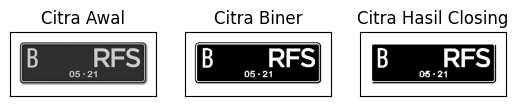

In [16]:
img = cv2.imread('/content/drive/MyDrive/Images/plat_nomor.png',0)
ret, thresh = cv2.threshold(img, 127, 225, cv2.THRESH_BINARY)
kernel = np.ones((3,3),np.uint8)
closs = cv2.morphologyEx(thresh,cv2.MORPH_CLOSE, kernel)
plt.subplot(131),plt.imshow(img,cmap = 'gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(thresh,cmap = 'gray')
plt.title('Citra Biner'), plt.xticks([]), plt.yticks([])
plt.subplot(133),plt.imshow(closs,cmap = 'gray')
plt.title('Citra Hasil Closing'), plt.xticks([]), plt.yticks([])
plt.show()

SED = Cross 3


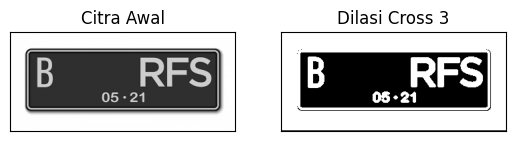

SED = Cross 5


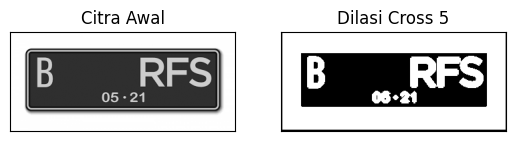

In [18]:
def dilasi_citra(F, SED):
    # Ukuran citra
    p, q = F.shape
    w = SED.shape[0]
    offset = (w - 1) // 2
    imgD = np.zeros((p, q), dtype=np.uint8)

    # Proses dilasi
    for i in range(offset, p - offset):
        for j in range(offset, q - offset):
            temp = F[i - offset:i + offset + 1, j - offset:j + offset + 1]
            product = temp * SED
            imgD[i, j] = np.max(product)

    return imgD

# Struktur elemen silang ukuran 3x3
SED3 = np.array([[0, 1, 0],
                 [1, 1, 1],
                 [0, 1, 0]], dtype=np.uint8)

print('SED = Cross 3')
img_d = cv2.imread('/content/drive/MyDrive/Images/plat_nomor.png', 0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)
imgD3 = dilasi_citra(thresh, SED3)

plt.subplot(121), plt.imshow(img_d, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(imgD3, cmap='gray')
plt.title('Dilasi Cross 3'), plt.xticks([]), plt.yticks([])
plt.show()

# Struktur elemen silang ukuran 5x5
SED5 = np.array([[0, 0, 1, 0, 0],
                 [0, 0, 1, 0, 0],
                 [1, 1, 1, 1, 1],
                 [0, 0, 1, 0, 0],
                 [0, 0, 1, 0, 0]], dtype=np.uint8)

print('SED = Cross 5')
img_d = cv2.imread('/content/drive/MyDrive/Images/plat_nomor.png', 0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)
imgD5 = dilasi_citra(thresh, SED5)

plt.subplot(121), plt.imshow(img_d, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(imgD5, cmap='gray')
plt.title('Dilasi Cross 5'), plt.xticks([]), plt.yticks([])
plt.show()


SED = Circle 3


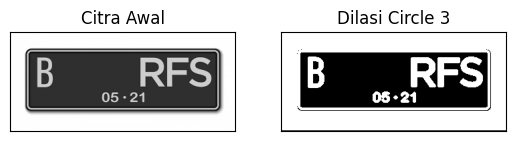

SED = Circle 5


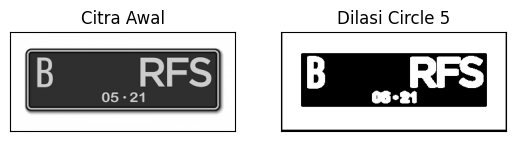

In [21]:
def dilasi_citra(F, w):
    # Ukuran citra
    p, q = F.shape
    imgD = np.zeros((p, q), dtype=np.uint8)

    # Struktur elemen berbentuk lingkaran
    SED = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (w, w))
    offset = (w - 1) // 2

    # Proses dilasi
    for i in range(offset, p - offset):
        for j in range(offset, q - offset):
            temp = F[i - offset:i + offset + 1, j - offset:j + offset + 1]
            product = temp * SED
            imgD[i, j] = np.max(product)

    return imgD

# Dilasi dengan SED lingkaran ukuran 3
print('SED = Circle 3')
img_d = cv2.imread('/content/drive/MyDrive/Images/plat_nomor.png', 0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)
imgD3 = dilasi_citra(thresh, 3)

plt.subplot(121), plt.imshow(img_d, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(imgD3, cmap='gray')
plt.title('Dilasi Circle 3'), plt.xticks([]), plt.yticks([])
plt.show()

# Dilasi dengan SED lingkaran ukuran 5
print('SED = Circle 5')
img_d = cv2.imread('/content/drive/MyDrive/Images/plat_nomor.png', 0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)
imgD5 = dilasi_citra(thresh, 5)

plt.subplot(121), plt.imshow(img_d, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(imgD5, cmap='gray')
plt.title('Dilasi Circle 5'), plt.xticks([]), plt.yticks([])
plt.show()


SE = Rectangle 3x5


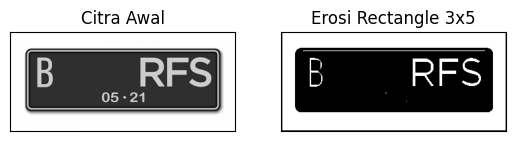

SE = Rectangle 5x7


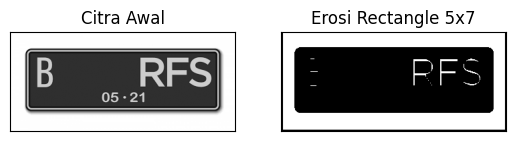

In [22]:
def erosi_citra(F, p, l):
    # Ukuran citra
    m, n = F.shape
    imgE = np.zeros((m, n), dtype=np.uint8)

    # Struktur elemen erosi berbentuk persegi panjang
    SE = cv2.getStructuringElement(cv2.MORPH_RECT, (p, l))
    offset_x = (p - 1) // 2
    offset_y = (l - 1) // 2

    # Proses erosi
    for i in range(offset_y, m - offset_y):
        for j in range(offset_x, n - offset_x):
            temp = F[i - offset_y:i + offset_y + 1, j - offset_x:j + offset_x + 1]
            product = temp * SE
            imgE[i, j] = np.min(product)

    return imgE

def tampilkan_hasil(img_awal, img_erosi, judul):
    plt.subplot(121), plt.imshow(img_awal, cmap='gray')
    plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
    plt.subplot(122), plt.imshow(img_erosi, cmap='gray')
    plt.title(judul), plt.xticks([]), plt.yticks([])
    plt.show()

# Erosi dengan SE ukuran 3x5
print('SE = Rectangle 3x5')
img_e = cv2.imread('/content/drive/MyDrive/Images/plat_nomor.png', 0)
ret1, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)
imgE1 = erosi_citra(thresh1, 5, 3)
tampilkan_hasil(img_e, imgE1, 'Erosi Rectangle 3x5')

# Erosi dengan SE ukuran 5x7
print('SE = Rectangle 5x7')
img_e = cv2.imread('/content/drive/MyDrive/Images/plat_nomor.png', 0)
ret2, thresh2 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)
imgE2 = erosi_citra(thresh2, 7, 5)
tampilkan_hasil(img_e, imgE2, 'Erosi Rectangle 5x7')


SE = Line Vertikal 3


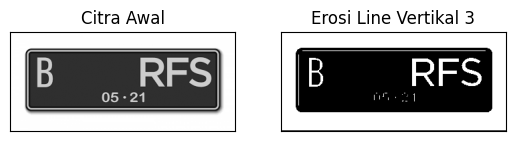

SE = Line Vertikal 5


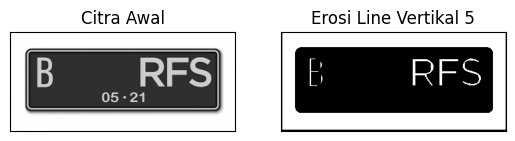

In [23]:
def erosi_citra(F, k):
    # Ukuran citra
    m, n = F.shape
    imgE = np.zeros((m, n), dtype=np.uint8)

    # Struktur elemen erosi berbentuk garis vertikal
    SE = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (1, k))
    offset = (k - 1) // 2

    # Proses erosi
    for i in range(offset, m - offset):
        for j in range(offset, n - offset):
            temp = F[i - offset:i + offset + 1, j - offset:j + offset + 1]
            product = temp * SE
            imgE[i, j] = np.min(product)

    return imgE

def tampilkan_hasil(img_awal, img_erosi, judul):
    plt.subplot(121), plt.imshow(img_awal, cmap='gray')
    plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
    plt.subplot(122), plt.imshow(img_erosi, cmap='gray')
    plt.title(judul), plt.xticks([]), plt.yticks([])
    plt.show()

# Erosi dengan SE garis vertikal ukuran 3
print('SE = Line Vertikal 3')
img_e = cv2.imread('/content/drive/MyDrive/Images/plat_nomor.png', 0)
ret1, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)
imgE3 = erosi_citra(thresh1, 3)
tampilkan_hasil(img_e, imgE3, 'Erosi Line Vertikal 3')

# Erosi dengan SE garis vertikal ukuran 5
print('SE = Line Vertikal 5')
img_e = cv2.imread('/content/drive/MyDrive/Images/plat_nomor.png', 0)
ret2, thresh2 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)
imgE5 = erosi_citra(thresh2, 5)
tampilkan_hasil(img_e, imgE5, 'Erosi Line Vertikal 5')


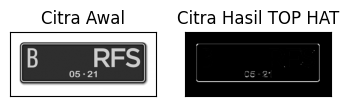

In [25]:
# Getting the kernel to be used in Top-Hat
filterSize =(3, 3)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT,
filterSize)
# Reading the image named 'input.jpg'
img = cv2.imread('/content/drive/MyDrive/Images/plat_nomor.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Applying the Top-Hat operation
tophat_img = cv2.morphologyEx(img,cv2.MORPH_TOPHAT,kernel)
#cv2.imshow("original", input_image)
#cv2.imshow("tophat", tophat_img)
#cv2.waitKey(5000)
plt.subplot(131),plt.imshow(img,cmap = 'gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(tophat_img,cmap = 'gray')
plt.title('Citra Hasil TOP HAT'), plt.xticks([]), plt.yticks([])
plt.show()

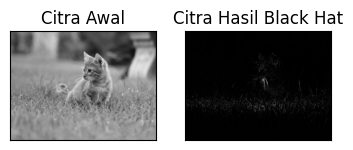

In [29]:
filterSize =(3, 3)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, filterSize)
# Reading the image named 'input.jpg'
img = cv2.imread('/content/drive/MyDrive/Images/kitten.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Applying the Black-Hat operation
#tophat_img = cv2.morphologyEx(img,cv2.MORPH_BLACKHAT, kernel)
Kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (13, 5))
blackhat = cv2.morphologyEx(img, cv2.MORPH_BLACKHAT, Kernel)
#cv2.imshow("original", input_image)
#cv2.imshow("tophat", tophat_img)
#cv2.waitKey(5000)
plt.subplot(131),plt.imshow(img,cmap = 'gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(blackhat,cmap = 'gray')
plt.title('Citra Hasil Black Hat'), plt.xticks([]), plt.yticks([])
plt.show()

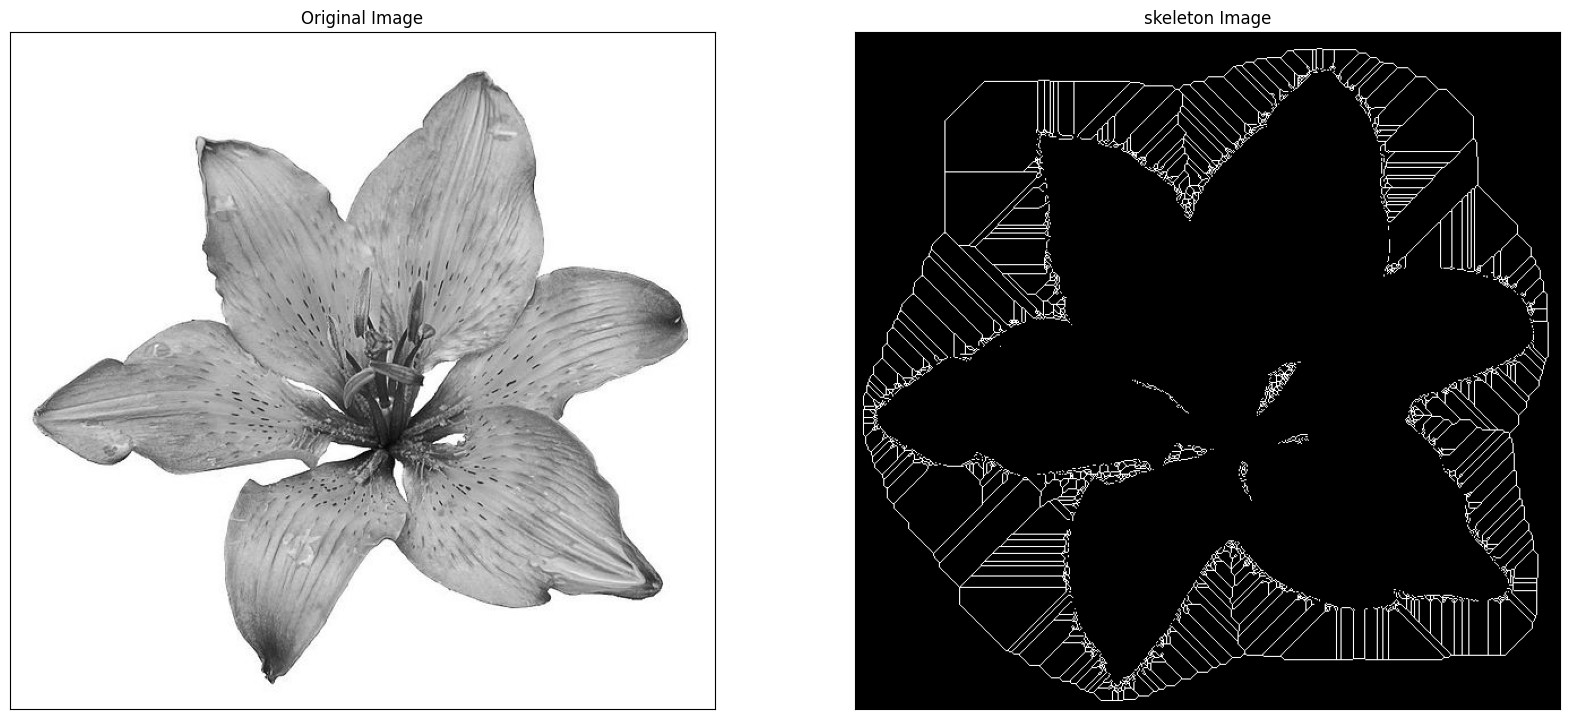

In [30]:
import cv2 as cv
from matplotlib import pyplot as plt
from skimage import filters
from skimage.morphology import skeletonize
# read image
img = cv.imread('/content/drive/MyDrive/Images/lily.jpg',0)
binary = img > filters.threshold_triangle(img)
# true false to one
binary_cp = binary.copy()
binary_cp[binary_cp == True] = 1
binary_cp[binary_cp == False] = 0
# skeletonize image
skeleton = skeletonize(binary_cp)
# print images
plt.figure(figsize=(20,20))
plt.subplot(121),plt.imshow(img,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(skeleton,cmap = 'gray')
plt.title('skeleton Image'), plt.xticks([]), plt.yticks([])
plt.savefig("binary and bin_skeleton.png")
plt.show()

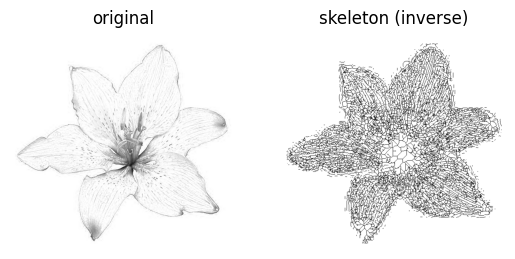

In [32]:
from skimage import io
from matplotlib import pyplot as plt
from skimage import filters
from skimage.morphology import skeletonize
# read image
img = io.imread('/content/drive/MyDrive/Images/lily.jpg')[...,0]
# Note: we want the black bits to be True, so use <
binary = img < filters.threshold_triangle(img)
# skeletonize image
skeleton = skeletonize(binary)
# print images
fig, ax = plt.subplots(1, 2)
ax[0].imshow(img, cmap='gray')
ax[0].set_title('original')
ax[0].set_axis_off()
# note the reversed colormap, gray_r
ax[1].imshow(skeleton, cmap='gray_r')
ax[1].set_title('skeleton (inverse)')
ax[1].set_axis_off()
plt.show()

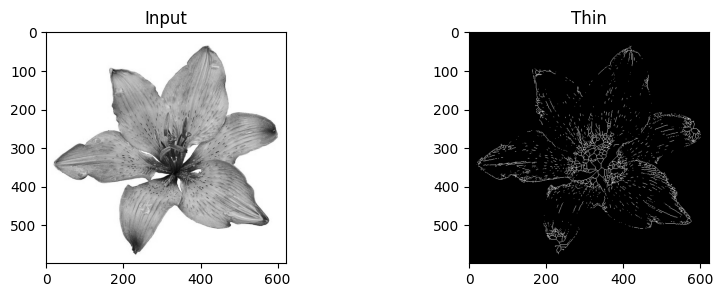

In [34]:
from skimage import img_as_float
from skimage import io, color, morphology
import matplotlib.pyplot as plt
image = img_as_float(color.rgb2gray(io.imread('/content/drive/MyDrive/Images/lily.jpg')))
image_binary = image < 0.5
out_skeletonize = morphology.skeletonize(image_binary)
out_thin = morphology.thin(image_binary)
f, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 3))
ax0.imshow(image, cmap='gray')
ax0.set_title('Input')
ax1.imshow(out_thin, cmap='gray')
ax1.set_title('Thin')
plt.savefig('/tmp/char_out.png')
plt.show()